# Exercise 2: Spam Classification using SVM

Using SVM, classify emails as spam or not spam based on word frequency and message length features.

In [1]:
# CH.SC.U4CSE24119 Kavin JS

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn import metrics
import seaborn as sn

## Importing Dataset

In [2]:
# Spambase dataset: 4601 rows x 58 columns (last column = label: 1=spam, 0=not spam)
# Features are word frequencies and character frequencies
data = pd.read_csv('../Data/spambase.data', header=None)
print('Shape:', data.shape)
print('\nFirst 5 rows:')
print(data.head())
print('\nLabel distribution (last column):')
print(data[57].value_counts())

Shape: (4601, 58)

First 5 rows:
     0     1     2    3     4     5     6     7     8     9   ...    48  \
0  0.00  0.64  0.64  0.0  0.32  0.00  0.00  0.00  0.00  0.00  ...  0.00   
1  0.21  0.28  0.50  0.0  0.14  0.28  0.21  0.07  0.00  0.94  ...  0.00   
2  0.06  0.00  0.71  0.0  1.23  0.19  0.19  0.12  0.64  0.25  ...  0.01   
3  0.00  0.00  0.00  0.0  0.63  0.00  0.31  0.63  0.31  0.63  ...  0.00   
4  0.00  0.00  0.00  0.0  0.63  0.00  0.31  0.63  0.31  0.63  ...  0.00   

      49   50     51     52     53     54   55    56  57  
0  0.000  0.0  0.778  0.000  0.000  3.756   61   278   1  
1  0.132  0.0  0.372  0.180  0.048  5.114  101  1028   1  
2  0.143  0.0  0.276  0.184  0.010  9.821  485  2259   1  
3  0.137  0.0  0.137  0.000  0.000  3.537   40   191   1  
4  0.135  0.0  0.135  0.000  0.000  3.537   40   191   1  

[5 rows x 58 columns]

Label distribution (last column):
57
0    2788
1    1813
Name: count, dtype: int64


## Assigning dependent and independent variables

In [3]:
x = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

## Splitting the dataset into Training and Testing Dataset

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=5)
display(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(3220, 57)

(3220,)

(1381, 57)

(1381,)

## Preprocessing Data with StandardScaler

In [5]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

## Fitting the Model (SVM) using 'rbf' kernel

In [6]:
model = SVC(kernel='rbf', random_state=0)
model.fit(x_train, y_train)
svc_prediction = model.predict(x_test)

## Evaluation Metrics

In [7]:
conf_mat = metrics.confusion_matrix(y_test, svc_prediction)
print('SVC [ kernel - rbf ]')
print('Confusion Matrix : \n', conf_mat)
Accuracy_score = metrics.accuracy_score(y_test, svc_prediction)
print('Accuracy Score : ', Accuracy_score)
print('Accuracy in Percentage : ', int(Accuracy_score * 100), '%')
print(classification_report(svc_prediction, y_test))

SVC [ kernel - rbf ]
Confusion Matrix : 
 [[816  36]
 [ 60 469]]
Accuracy Score :  0.9304851556842868
Accuracy in Percentage :  93 %
              precision    recall  f1-score   support

           0       0.96      0.93      0.94       876
           1       0.89      0.93      0.91       505

    accuracy                           0.93      1381
   macro avg       0.92      0.93      0.93      1381
weighted avg       0.93      0.93      0.93      1381



## Confusion Matrix Heatmap

[Text(0.5, 1.0, 'SVC Spam Classification [rbf]')]

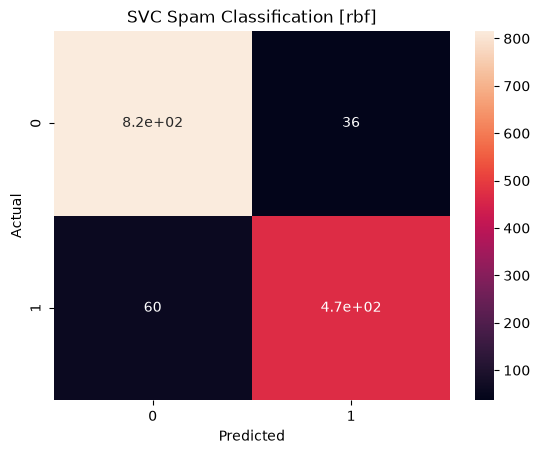

In [8]:
conf_mat = pd.crosstab(y_test, svc_prediction, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(conf_mat, annot=True).set(title='SVC Spam Classification [rbf]')